# Several-fish reusable calcium analysis

Edit only `USER_SETTINGS` for each experiment. The notebook runs one experiment at a time, and each output section can be turned on or off.

In [1]:
# Cell 01 - Setup
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import importlib

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import src.data_loading as exio
import src.analysis_tools as at
import src.multifish_analysis as mfa
import src.plotting as plott
import src.reusable_several_fish as rsf

importlib.reload(exio)
importlib.reload(at)
importlib.reload(mfa)
importlib.reload(plott)
importlib.reload(rsf)


<module 'src.reusable_several_fish' from 'c:\\Users\\larsch-lab\\code\\social_filters\\src\\reusable_several_fish.py'>

In [2]:
# Cell 02 - USER SETTINGS
# Change this block for each experiment. The cells below should not need edits.
#
# Quick guide:
# - Put the experiment folder name in experiment_name.
# - Put only the fish you want to include in fish_ids.
# - Put the stimulus names for each plot type in stimulus_sets.
# - Turn plots on/off in outputs.
# - If a stimulus set is None, the notebook reuses a sensible default.
# - Stimulus names must match the detected names printed after loading.

USER_SETTINGS = {
    # Experiment and data location.
    # experiment_name must match the folder suffix used by the data loader, e.g.
    # "Exp_5_map_positions", "Exp_7_trans_stat", "Exp_2_rocking_1".
    "experiment_name": "Exp_8_accumulation_ev",

    # Base folder that contains the OneDrive Lab/Data and Lab/Analysis folders.
    # Usually this can stay unchanged on this computer.
    "data_base": Path(r"D:\\Alejandro\\Data"),

    # Fish to include in this run. Add/remove IDs here for each experiment.
    "fish_ids": [
        "L800_f02",
        "L800_f03", 
        "L800_f09",
        #"L800_f10",
        #"L800_f11",
        "L800_f04",
        "L800_f05",
       "L800_f07",

    ],

    # Blocks to load. Examples:
    # [f"B{n}" for n in range(1, 5)] -> B1, B2, B3, B4
    # ["B1", "B2"] -> only two blocks
    "selected_blocks": [f"B{n}" for n in range(1, 5)],

    # Label used in plot titles/tables. Examples: "Left", "Right", "All", "Map positions".
    "analysis_label": "Right",

    # True prints more loading/alignment details. False keeps the notebook quieter.
    "verbose_loading": False,

    # Timing controls for alignment and response windows.
    "timing": {
        "fps_2p": 2.0,                 # 2P imaging frame rate.
        "t_pre_s": 5.0,                # seconds before stimulus onset in aligned traces.
        "t_post_s": 25.0,              # seconds after stimulus onset in aligned traces.
        "motion_onset_s": 8.0,         # when motion starts inside the stimulus epoch.
        "tau_s": 6.0,                  # extra response tail after motion duration.
        "motion_duration_key": "motion_sec",  # usually "motion_sec".
    },

    # Stimulus sets can be different for different output types.
    # Use names, not IDs, whenever possible. The detected names are printed after loading.
    "stimulus_sets": {
        # Full neuron-by-stimulus response matrix.
        # None = all detected stimuli. Use a list to restrict it, e.g. ["LeB1", "LeB2"].
        "response_matrix": None,

        # Main neuron-level comparison plots: similarity, stimulus specificity, selected rasters.
        "main_plots": [16,15,14,13,12,11,10,9],

        # Mean time-course plot. Often useful to include controls here.
        "mean_traces": [16,15,14,13,12,11,10,9],

        # Motion-delta plots. None = use mean_traces. Or set a custom list.
        "motion_delta": None,

        # Active-neuron overlap/Jaccard groups. Rename the lists per experiment.
        "overlap_left": [5,4,3,2,1,8,7,6],
        "overlap_right": [16,15,14,13,12,11,10,9],
    },

    # Active-neuron decision from significant rasters.
    "active_neurons": {
        "active_fraction_threshold": 0.10,  # fraction of motion-window frames active within a trial.
        "min_epoch_s": 1.0,                 # minimum active epoch length in seconds.
        "min_active_reps": 2,               # minimum repetitions that must pass.
        "expected_reps": 4,                 # expected trial count per stimulus.
        "require_expected_reps": True,      # False allows unequal/missing repetition counts.
    },

    # Optional neuron filter based on two control/anchor stimuli.
    # Index formula is (left_response - right_response) / (left_response + right_response).
    # left_right_filter_mode options:
    # - "none": keep all neurons
    # - "abs": keep strong left OR right preference, abs(index) >= threshold
    # - "left": keep left-preferring neurons, index >= threshold
    # - "right": keep right-preferring neurons, index <= -threshold
    # - "range": keep neurons inside left_right_range
    "neuron_filter": {
        "left_right_controls": (5, 16),
        "left_right_filter_mode": "none",  # "none", "abs", "left", "right", or "range".
        "left_right_threshold": 0.3,
        "left_right_range": (-0.3, 1.0),
    },

    # General plotting options.
    "plot_options": {
        "lifetime_sparseness_threshold": 0.65,
        "combine_mode": "concat",       # "mean" averages repetitions; "concat" concatenates repetitions.
        "raster_sort_mode": "unsorted", # examples used by plotting helper: "corravg", "kmeans", "unsorted".
        "n_clusters": 3,               # used only for cluster-based sorting.
        "random_state": 0,
        "zscore_vmax": 4,
        "high_sparseness_vmax": 4,
        "motion_delta_fish_id": None,  # None = first fish; or set a fish ID string.
        "apply_neuron_filter_to_cell06": True,  # True = mean traces and motion-delta use neuron_filter.
    },

    # Overlap and diagnostic plot options.
    "overlap_diagnostic": {
        "plot": "z_score",  # "significant_raster" or "z_score".
        "side": "right",                # which overlap group to plot in the diagnostic: "left" or "right".
        "aggregation": "mean_per_fish", # "pooled" pools neurons; "mean_per_fish" averages fish matrices.
        "sort_mode": "decision_then_mean", # "decision_then_mean", "left_right_index", "lifetime_sparseness".
        "combine_mode": "mean",        # "mean" or "concat" for trace blocks.
        "show_active_count": True,
        "active_count_threshold": 0.5,   # used for active-count trace in z-score mode.
        "heatmap_figsize": (5, 4),
        "heatmap_cmap": "viridis",
        "heatmap_annot": True,
    },

    # Turn outputs on/off here to avoid running slow or irrelevant plots.
    "outputs": {
        "response_window_validation": True, # table checking response windows per fish/stimulus.
        "similarity": True,                 # stimulus-vector similarity heatmaps.
        "stimulus_specificity":True,     # sparseness, active-count, preferred-stimulus plots.
        "high_sparseness_raster": False,     # selected high-sparseness z-score raster.
        "selected_zscore_raster": True,     # z-score raster for main_plots.
        "selected_active_raster": True,     # binary significant-response raster for main_plots.
        "mean_traces": True,                # mean time-course line plot.
        "motion_delta": True,               # integral and peak motion-minus-fixed plots.
        "overlap_diagnostic": True,         # Jaccard overlap heatmap and active-decision diagnostic.
    },
}

# Report settings for preserving important notebook runs.
# Keep save_report=False while exploring. Set it to True only for runs worth keeping.
REPORT_SETTINGS = {
    "save_report": False,
    "run_label": "Right_side_concat_filtered_by_right_index",
    "report_format": "pdf",  # "pdf", "html", or "both".
    "export_notebook": True,
    "fallback_to_html": True,  # Saves HTML if PDF export is unavailable.
    "comments": """
Goal:
Here we are running fish that resposd to stimuli on the rigth side,



Notes:

r

list of fish

descarted: 1, 6 , 8 = bad signals
used for left= 10, 11
used for right= 4,5,7
both= 2,3,9

Conclusion:
Write the main conclusion after reviewing the outputs.
""",
}


In [3]:
# Cell 03 - Load, resolve stimuli, and build reusable tables
settings = USER_SETTINGS
timing = settings["timing"]
stimulus_sets = settings["stimulus_sets"]
outputs = settings["outputs"]
plot_options = settings["plot_options"]

onedrive_base = settings["data_base"]
onedrive_candidates = [
    onedrive_base / "OneDrive - Universite de Lausanne",
    *sorted(onedrive_base.glob("OneDrive - Universit* de Lausanne")),
]

def first_existing_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    tried = "\n".join(str(Path(candidate)) for candidate in candidates)
    raise FileNotFoundError("None of the configured root paths exists:\n" + tried)

onedrive_root = first_existing_path(*onedrive_candidates)
main_path = onedrive_root / "Lab" / "Data" / "2p"
analysis_path = onedrive_root / "Lab" / "Analysis"
stimuli_main_path = analysis_path
save_path = analysis_path / settings["experiment_name"] / "plots"
fish_ids = list(settings["fish_ids"])

print("Experiment:", settings["experiment_name"])
print("Fish:", fish_ids)
print("main_path:", main_path)

all_fish_data = {}
for fish_id in fish_ids:
    print(f"Loading {fish_id}")
    all_fish_data[fish_id] = exio.load_and_align_2p_experiment(
        fish_id=fish_id,
        experiment_name=settings["experiment_name"],
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=timing["fps_2p"],
        selected_blocks=settings["selected_blocks"],
        t_pre_s=timing["t_pre_s"],
        t_post_s=timing["t_post_s"],
        verbose=settings["verbose_loading"],
    )

reference_fish_id = fish_ids[0]
reference_fish = all_fish_data[reference_fish_id]
print("Detected stimuli:", reference_fish["stimuli_names"])

response_selection = rsf.resolve_stimulus_set(stimulus_sets["response_matrix"], reference_fish)
response_stimulus_ids = response_selection["stimulus_ids"]
response_stimulus_labels = response_selection["stimulus_labels"]

main_selection = rsf.resolve_stimulus_set(
    stimulus_sets["main_plots"],
    reference_fish,
    fallback_labels=response_stimulus_labels,
)
plot_stimulus_ids = main_selection["stimulus_ids"]
plot_stimulus_labels = main_selection["stimulus_labels"]

stimuli_colors, stimuli_linestyles = plott.build_stimulus_style_maps(stimuli_names=response_stimulus_labels)
stimuli_durations = reference_fish["stimuli_durations"]

if outputs["response_window_validation"]:
    response_window_validation = rsf.build_response_window_validation(
        all_fish_data=all_fish_data,
        fish_ids=fish_ids,
        stimulus_ids=response_stimulus_ids,
        stimulus_labels=response_stimulus_labels,
        fps_2p=timing["fps_2p"],
        t_pre_s=timing["t_pre_s"],
        motion_onset_s=timing["motion_onset_s"],
        tau_s=timing["tau_s"],
        motion_duration_key=timing["motion_duration_key"],
    )

response_results = mfa.build_zscore_response_matrices_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    selected_stimuli=response_stimulus_labels,
    fps_2p=timing["fps_2p"],
    t_pre_s=timing["t_pre_s"],
    motion_onset_s=timing["motion_onset_s"],
    tau_s=timing["tau_s"],
    motion_duration_key=timing["motion_duration_key"],
)
response_matrices_by_fish = response_results["response_matrices"]
pooled_response_matrix = response_results["pooled_response_matrix"]
response_row_metadata = response_results["row_metadata"]

active_matrices = mfa.build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    stim_order=response_stimulus_ids,
    fps_2p=timing["fps_2p"],
    t_pre_s=timing["t_pre_s"],
    motion_onset_s=timing["motion_onset_s"],
    tau_s=timing["tau_s"],
    motion_duration_key=timing["motion_duration_key"],
    **settings["active_neurons"],
)

filter_settings = settings["neuron_filter"]
summary_results = rsf.build_selected_neuron_summary(
    response_matrices=response_matrices_by_fish,
    pooled_response_matrix=pooled_response_matrix,
    response_row_metadata=response_row_metadata,
    active_matrices=active_matrices,
    response_stimulus_ids=response_stimulus_ids,
    response_stimulus_labels=response_stimulus_labels,
    plot_stimulus_ids=plot_stimulus_ids,
    plot_stimulus_labels=plot_stimulus_labels,
    analysis_label=settings["analysis_label"],
    preference_controls=filter_settings["left_right_controls"],
    filter_mode=filter_settings["left_right_filter_mode"],
    filter_threshold=filter_settings["left_right_threshold"],
    filter_range=filter_settings["left_right_range"],
)
neuron_summary_table = summary_results["neuron_summary_table"]
neuron_summary_all_stimuli_table = summary_results["neuron_summary_all_stimuli_table"]
plot_neuron_keep_mask = summary_results["plot_neuron_keep_mask"]
resolved_preference_controls = summary_results["resolved_preference_controls"]
left_right_index = summary_results["left_right_index"]
selected_auc_response_matrix = summary_results["selected_auc_response_matrix"]
plot_filter_table = summary_results["plot_filter_table"]

shape_summary = pd.DataFrame([
    {
        "fish_id": fid,
        "response_rows": response_matrices_by_fish[fid].shape[0],
        "kept_neurons": len(all_fish_data[fid]["kept_neuron_indices"]),
        "response_columns": response_matrices_by_fish[fid].shape[1],
    }
    for fid in fish_ids
])

print("Response matrix stimuli:", response_stimulus_labels)
print("Main plot stimuli:", plot_stimulus_labels)
print("Left/right controls resolved to:", resolved_preference_controls)
print("Pooled response matrix:", pooled_response_matrix.shape)
print(f"Finite left_right_index values: {int(np.isfinite(left_right_index).sum())} of {left_right_index.size}")
print(f"Plot filter kept {int(plot_neuron_keep_mask.sum())} of {plot_neuron_keep_mask.size} neurons")
display(shape_summary)
if outputs["response_window_validation"]:
    display(response_window_validation.groupby("stimulus")["n_response_frames"].describe())
display(plot_filter_table.head())


Experiment: Exp_8_accumulation_ev
Fish: ['L800_f02', 'L800_f03', 'L800_f09', 'L800_f04', 'L800_f05', 'L800_f07']
main_path: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p
Loading L800_f02
Loaded significant traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f02_Exp_8_accumulation_ev\03_analysis\functional\plots\significant_traces\L800_f02_significant_traces.npz
Loaded kept_neuron_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f02_Exp_8_accumulation_ev\03_analysis\functional\plots\filtered_neurons_by_stimuli\L800_f02_kept_neuron_indices.npy
Loaded filtered_roi_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f02_Exp_8_accumulation_ev\03_analysis\functional\suite2P\merged_dFoF\L800_f02_dFoF_merged_filtered_roi_indices.npy
Loaded z_traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f02_Exp_8_accumulation_ev\03_analysis\functional\plots\z_core\L80

,fish_id,response_rows,kept_neurons,response_columns
0,L800_f02,380,380,16
1,L800_f03,192,192,16
2,L800_f09,549,549,16
3,L800_f04,424,424,16
4,L800_f05,441,441,16
5,L800_f07,250,250,16


,count,mean,std,min,25%,50%,75%,max
stimulus,,,,,,,,
LeB,6.0,34.0,0.0,34.0,34.0,34.0,34.0,34.0
LeBseg1,6.0,34.0,0.0,34.0,34.0,34.0,34.0,34.0
LeBseg135,6.0,34.0,0.0,34.0,34.0,34.0,34.0,34.0
LeBseg1rnd,6.0,34.0,0.0,34.0,34.0,34.0,34.0,34.0
LeBseg2,6.0,34.0,0.0,34.0,34.0,34.0,34.0,34.0
LeRock,6.0,34.0,0.0,34.0,34.0,34.0,34.0,34.0
Leflick1,6.0,34.0,0.0,34.0,34.0,34.0,34.0,34.0
Leflick5,6.0,34.0,0.0,34.0,34.0,34.0,34.0,34.0
RiB,6.0,34.0,0.0,34.0,34.0,34.0,34.0,34.0


,fish_id,neuron_id,source_neuron_id,global_neuron_id,left_right_index,plot_neuron_keep,left_right_left_control,left_right_right_control
0,L800_f02,0,2,0,0.864072,True,LeB,RiB
1,L800_f02,1,21,1,0.834022,True,LeB,RiB
2,L800_f02,2,22,2,0.573289,True,LeB,RiB
3,L800_f02,3,23,3,0.763174,True,LeB,RiB
4,L800_f02,4,24,4,0.191190,True,LeB,RiB


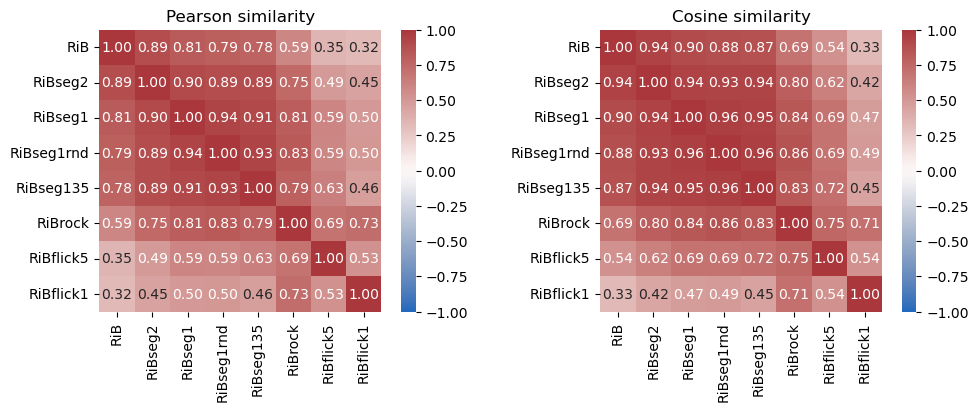

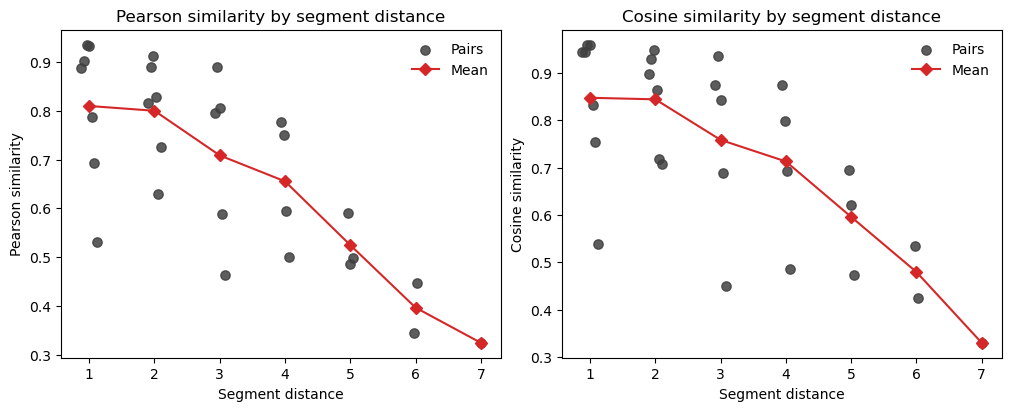

,stimulus_a,stimulus_b,segment_distance,pearson_similarity,cosine_similarity
0,RiB,RiBseg2,1,0.887887,0.943875
1,RiB,RiBseg1,2,0.814900,0.898236
2,RiB,RiBseg1rnd,3,0.794690,0.875121
3,RiB,RiBseg135,4,0.776040,0.874436
4,RiB,RiBrock,5,0.590188,0.694175
5,RiB,RiBflick5,6,0.345466,0.535102
6,RiB,RiBflick1,7,0.324504,0.329928
7,RiBseg2,RiBseg1,1,0.901906,0.944838
8,RiBseg2,RiBseg1rnd,2,0.889004,0.930179
9,RiBseg2,RiBseg135,3,0.889647,0.936112


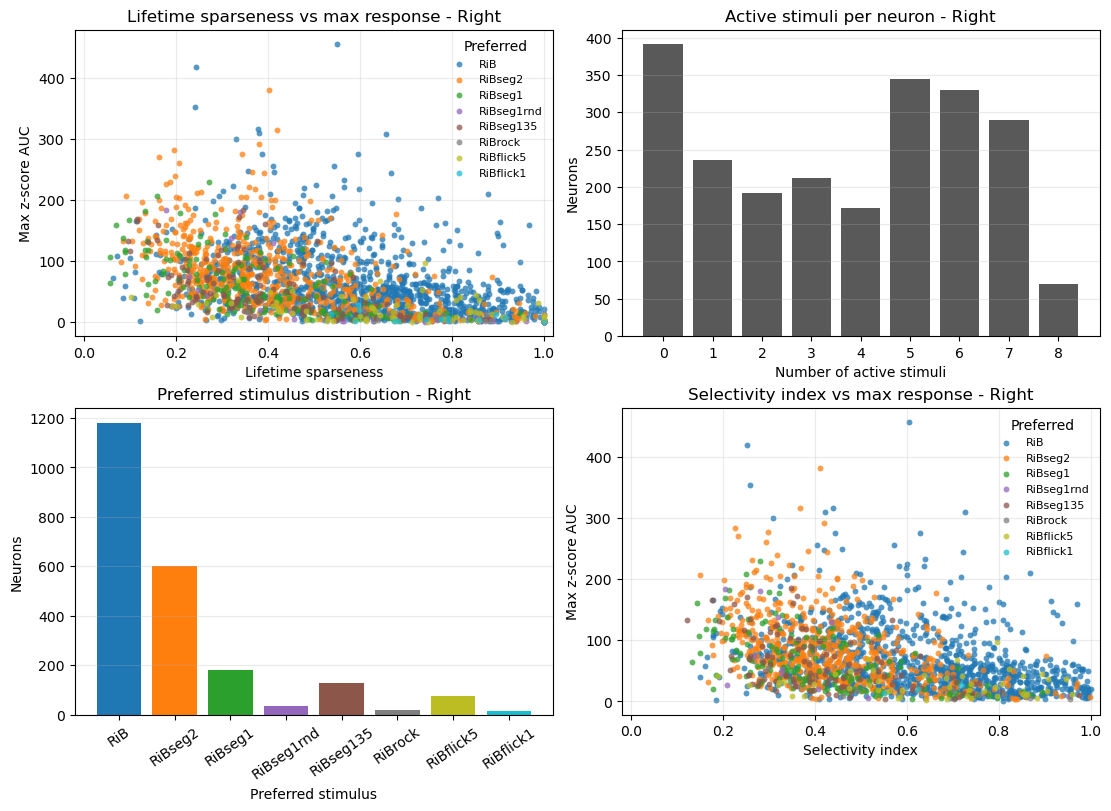

In [4]:
# Cell 04 - Optional: similarity and stimulus-specificity plots
if outputs["similarity"]:
    similarity_results = mfa.build_stimulus_vector_similarity(selected_auc_response_matrix, selected_stimuli=plot_stimulus_labels)
    pearson_similarity_matrix = similarity_results["pearson_similarity_matrix"]
    cosine_similarity_matrix = similarity_results["cosine_similarity_matrix"]
    segment_similarity_df = similarity_results["pair_similarity"]

    plott.plot_similarity_heatmaps(pearson_similarity_matrix, cosine_similarity_matrix)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
    plott.plot_similarity_by_distance(segment_similarity_df, "pearson_similarity", ax=axes[0])
    plott.plot_similarity_by_distance(segment_similarity_df, "cosine_similarity", ax=axes[1])
    plt.show()
    display(segment_similarity_df)

if outputs["stimulus_specificity"]:
    plot_summary_table = neuron_summary_table.loc[neuron_summary_table["plot_neuron_keep"]].reset_index(drop=True)
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
    plott.plot_stimulus_specificity_sparseness(plot_summary_table, plot_stimulus_labels, settings["analysis_label"], ax=axes[0, 0])
    plott.plot_active_stimuli_histogram(plot_summary_table, plot_stimulus_labels, settings["analysis_label"], ax=axes[0, 1])
    plott.plot_preferred_stimulus_distribution(plot_summary_table, plot_stimulus_labels, settings["analysis_label"], ax=axes[1, 0])
    plott.plot_stimulus_specificity_selectivity_index(plot_summary_table, plot_stimulus_labels, settings["analysis_label"], ax=axes[1, 1])
    plt.show()


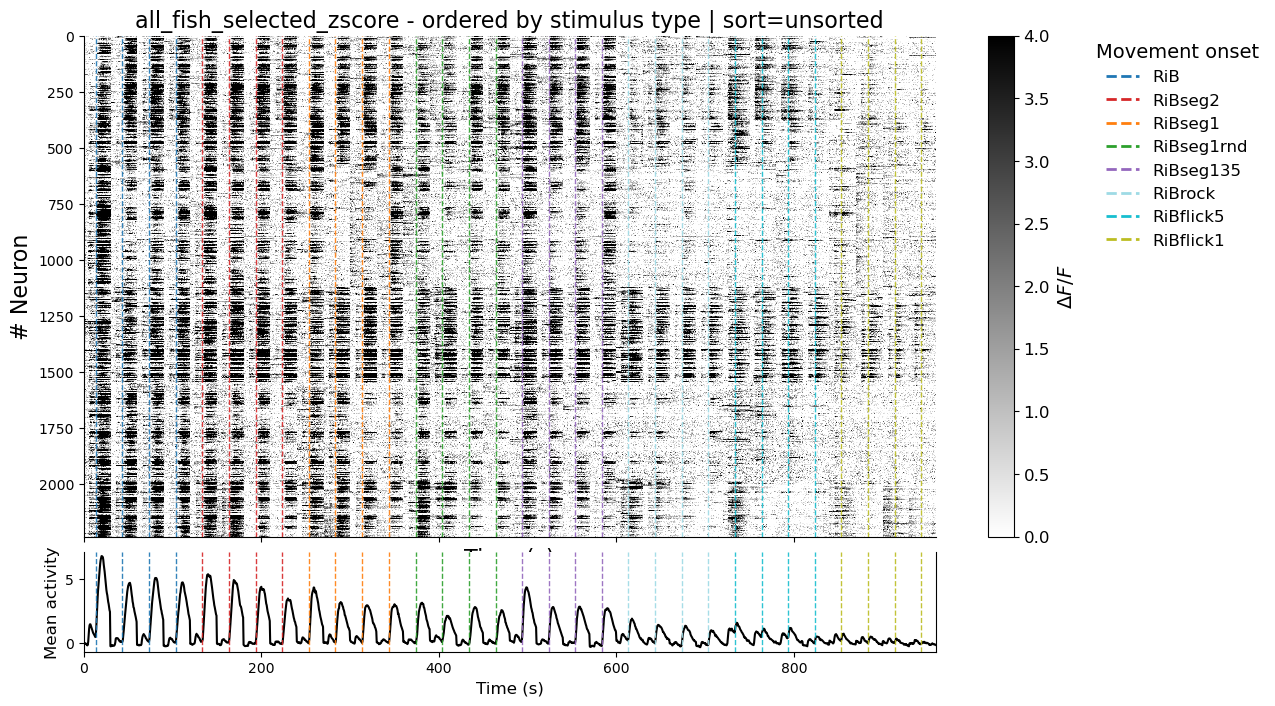

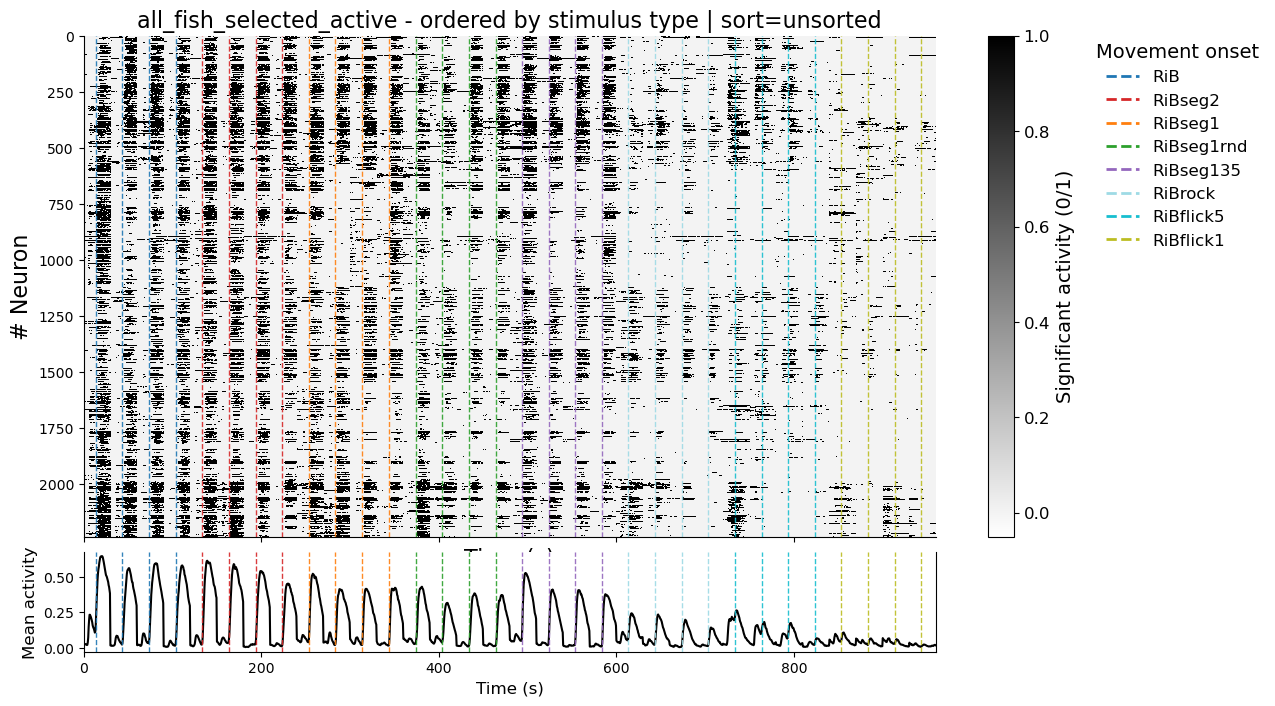

In [5]:
# Cell 05 - Optional: selected rasters
selected_raster_neuron_order = None

if outputs["high_sparseness_raster"]:
    high_sparseness = rsf.build_high_sparseness_raster_data(
        all_fish_data=all_fish_data,
        fish_ids=fish_ids,
        summary_table=neuron_summary_table,
        stim_order=plot_stimulus_ids,
        preferred_stimulus_order=plot_stimulus_labels,
        lifetime_sparseness_threshold=plot_options["lifetime_sparseness_threshold"],
        keep_mask=plot_neuron_keep_mask,
        combine_mode=plot_options["combine_mode"],
        trace_type="zscore",
    )
    print("High-sparseness neurons:", high_sparseness["matrix"].shape[0])
    display(high_sparseness["summary_table"].head())
    if high_sparseness["matrix"].shape[0] > 0:
        fig, ax, im, order = plott.plot_allfish_flat_raster(
            data=high_sparseness["matrix"],
            trial_aligned_traces=reference_fish["trial_aligned_traces_z_core"],
            stim_order=plot_stimulus_ids,
            stimuli_id_map=reference_fish["stimuli_id_map"],
            stimuli_durations=reference_fish["stimuli_durations"],
            stimuli_colors=stimuli_colors,
            stimuli_linestyles=stimuli_linestyles,
            fps_2p=timing["fps_2p"],
            t_pre_s=timing["t_pre_s"],
            combine_mode=plot_options["combine_mode"],
            sort_mode="unsorted",
            neuron_order=high_sparseness["plot_neuron_order"],
            sort_label=f"sparseness>{plot_options['lifetime_sparseness_threshold']}",
            is_binary=False,
            show_mean_trace=True,
            figsize=(12, 8),
            fish_id="all_fish_high_lifetime_sparseness_zscore",
            vmax=plot_options["high_sparseness_vmax"],
        )
        plt.show()

if outputs["selected_zscore_raster"]:
    selected_zscore_matrix = mfa.build_matrix_all_fish(all_fish_data, plot_stimulus_ids, fish_ids=fish_ids, combine_mode=plot_options["combine_mode"], trace_type="zscore")
    selected_zscore_matrix = selected_zscore_matrix[plot_neuron_keep_mask, :]
    fig, ax, im, selected_raster_neuron_order = plott.plot_allfish_flat_raster(
        data=selected_zscore_matrix,
        trial_aligned_traces=reference_fish["trial_aligned_traces_z_core"],
        stim_order=plot_stimulus_ids,
        stimuli_id_map=reference_fish["stimuli_id_map"],
        stimuli_durations=reference_fish["stimuli_durations"],
        stimuli_colors=stimuli_colors,
        stimuli_linestyles=stimuli_linestyles,
        fps_2p=timing["fps_2p"],
        t_pre_s=timing["t_pre_s"],
        combine_mode=plot_options["combine_mode"],
        sort_mode=plot_options["raster_sort_mode"],
        n_clusters=plot_options["n_clusters"],
        random_state=plot_options["random_state"],
        is_binary=False,
        show_mean_trace=True,
        figsize=(12, 8),
        fish_id="all_fish_selected_zscore",
        vmax=plot_options["zscore_vmax"],
    )
    plt.show()

if outputs["selected_active_raster"]:
    selected_active_matrix = mfa.build_matrix_all_fish(all_fish_data, plot_stimulus_ids, fish_ids=fish_ids, combine_mode=plot_options["combine_mode"], trace_type="raster")
    selected_active_matrix = selected_active_matrix[plot_neuron_keep_mask, :]
    fig, ax, im, selected_active_order = plott.plot_allfish_flat_raster(
        data=selected_active_matrix,
        trial_aligned_traces=reference_fish["trial_aligned_traces_raster"],
        stim_order=plot_stimulus_ids,
        stimuli_id_map=reference_fish["stimuli_id_map"],
        stimuli_durations=reference_fish["stimuli_durations"],
        stimuli_colors=stimuli_colors,
        stimuli_linestyles=stimuli_linestyles,
        fps_2p=timing["fps_2p"],
        t_pre_s=timing["t_pre_s"],
        combine_mode=plot_options["combine_mode"],
        sort_mode=plot_options["raster_sort_mode"],
        n_clusters=plot_options["n_clusters"],
        random_state=plot_options["random_state"],
        neuron_order=selected_raster_neuron_order,
        is_binary=True,
        show_mean_trace=True,
        figsize=(12, 8),
        fish_id="all_fish_selected_active",
        vmax=1,
    )
    plt.show()


Cell 06 neuron population: neuron_filter


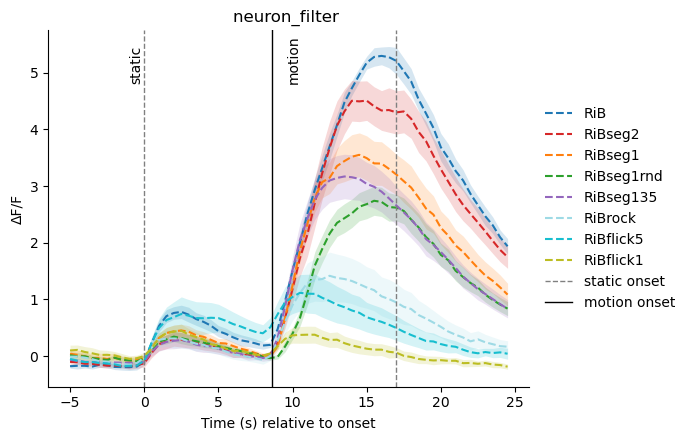

Motion-delta fish: L800_f02
Motion-delta neurons: 380
Motion-delta stimuli: ['RiB', 'RiBseg2', 'RiBseg1', 'RiBseg1rnd', 'RiBseg135', 'RiBrock', 'RiBflick5', 'RiBflick1']


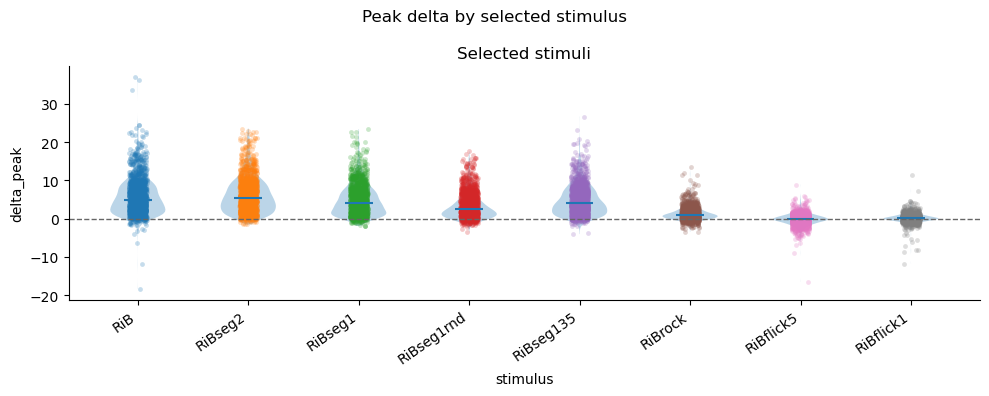

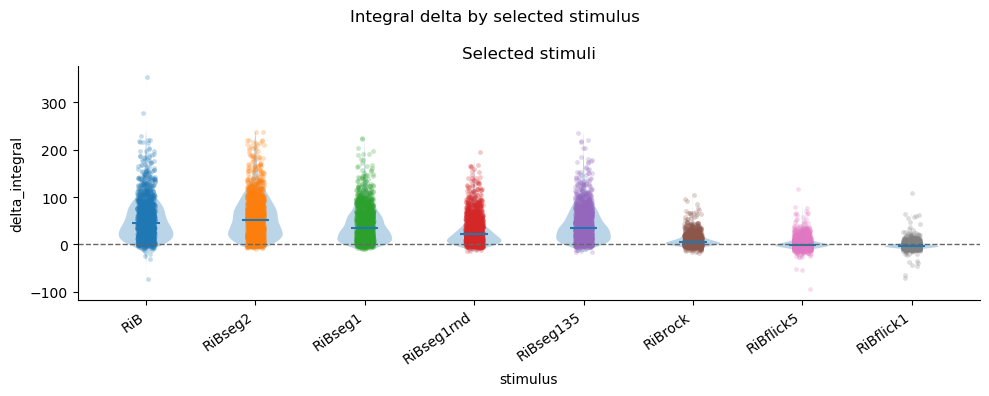

In [6]:
# Cell 06 - Optional: mean traces and motion-delta distributions
cell06_use_filter = bool(plot_options.get("apply_neuron_filter_to_cell06", True))
cell06_keep_mask = plot_neuron_keep_mask if cell06_use_filter else None
cell06_filter_label = "neuron_filter" if cell06_use_filter else "all preprocessed neurons"
print("Cell 06 neuron population:", cell06_filter_label)
if outputs["mean_traces"]:
    mean_selection = rsf.resolve_stimulus_set(stimulus_sets["mean_traces"], reference_fish, fallback_labels=plot_stimulus_labels)
    mean_stimulus_ids = mean_selection["stimulus_ids"]
    mean_stimulus_labels = mean_selection["stimulus_labels"]
    mean_trace_selection = rsf.build_pooled_mean_trace_by_stimulus(
        all_fish_data=all_fish_data,
        fish_ids=fish_ids,
        stim_order=mean_stimulus_ids,
        trace_type="zscore",
        use_kept_neurons=True,
        response_row_metadata=response_row_metadata,
        keep_mask=cell06_keep_mask,
    )
    fig_mean_traces, ax_mean_traces, used_colors, out_path = plott.plot_stimulus_means(
        mean_traces=mean_trace_selection,
        stimuli_ids=mean_stimulus_ids,
        stimuli_names=mean_stimulus_labels,
        title_prefix=f"{cell06_filter_label} ",
        fps_2p=timing["fps_2p"],
        t_post_s=timing["t_post_s"],
        t_pre_s=timing["t_pre_s"],
        stimuli_durations=stimuli_durations,
        plots_path=None,
        prefix=None,
        dpi=600,
        save=False,
        stimuli_colors=stimuli_colors,
        stimuli_linestyles=stimuli_linestyles,
        close_after=False,
        kept_cells=None,
        comment="all_stimuli",
    )
    plt.show()

if outputs["motion_delta"]:
    motion_selection_input = stimulus_sets["motion_delta"] or stimulus_sets["mean_traces"] or stimulus_sets["main_plots"]
    motion_selection = rsf.resolve_stimulus_set(motion_selection_input, reference_fish)
    motion_stimulus_ids = motion_selection["stimulus_ids"]
    motion_stimulus_labels = motion_selection["stimulus_labels"]
    fish_id = plot_options["motion_delta_fish_id"] or fish_ids[0]
    fish_data = all_fish_data[fish_id]
    fish_keep_mask = None
    if cell06_use_filter:
        fish_keep_mask = rsf.build_fish_keep_masks(
            response_row_metadata=response_row_metadata,
            keep_mask=plot_neuron_keep_mask,
            fish_ids=fish_ids,
        )[fish_id]
    selected_trial_aligned_z_kept = rsf.build_filtered_trial_aligned_traces_for_fish(
        fish_data=fish_data,
        stimulus_ids=motion_stimulus_ids,
        trace_key="trial_aligned_traces_z_core",
        fish_keep_mask=fish_keep_mask,
    )
    delta_df = at.compute_motion_delta_integrals(
        selected_trial_aligned_z_kept,
        fps_2p=timing["fps_2p"],
        t_pre_s=timing["t_pre_s"],
        pre_motion_fixed_s=timing["motion_onset_s"],
        stimuli_id_map=fish_data["stimuli_id_map"],
        stimuli_durations=fish_data["stimuli_durations"],
        fish_id=fish_id,
    )
    peak_df = at.compute_motion_delta_peaks(
        selected_trial_aligned_z_kept,
        fps_2p=timing["fps_2p"],
        t_pre_s=timing["t_pre_s"],
        pre_motion_fixed_s=timing["motion_onset_s"],
        stimuli_id_map=fish_data["stimuli_id_map"],
        stimuli_durations=fish_data["stimuli_durations"],
        fish_id=fish_id,
    )
    delta_df = delta_df[delta_df["stimulus"].isin(motion_stimulus_labels)].copy()
    peak_df = peak_df[peak_df["stimulus"].isin(motion_stimulus_labels)].copy()
    print("Motion-delta fish:", fish_id)
    print("Motion-delta neurons:", next(iter(selected_trial_aligned_z_kept.values())).shape[0])
    print("Motion-delta stimuli:", motion_stimulus_labels)
    plott.plot_motion_delta_distribution(peak_df, value_col="delta_peak", stimuli=motion_stimulus_labels, title="Peak delta by selected stimulus")
    plott.plot_motion_delta_distribution(delta_df, stimuli=motion_stimulus_labels, title="Integral delta by selected stimulus")


,LeB,LeBseg2,LeBseg1,LeBseg1rnd,LeBseg135,LeRock,Leflick5,Leflick1
LeB,1.000000,0.814494,0.499717,0.474680,0.514045,0.182078,0.202703,0.026903
LeBseg2,0.814494,1.000000,0.535280,0.531515,0.548465,0.197296,0.219261,0.027675
LeBseg1,0.499717,0.535280,1.000000,0.659672,0.661319,0.319149,0.331633,0.049020
LeBseg1rnd,0.474680,0.531515,0.659672,1.000000,0.658082,0.313953,0.337423,0.035370
LeBseg135,0.514045,0.548465,0.661319,0.658082,1.000000,0.303644,0.331693,0.035861
LeRock,0.182078,0.197296,0.319149,0.313953,0.303644,1.000000,0.352505,0.048780
Leflick5,0.202703,0.219261,0.331633,0.337423,0.331693,0.352505,1.000000,0.061033
Leflick1,0.026903,0.027675,0.049020,0.035370,0.035861,0.048780,0.061033,1.000000


,RiB,RiBseg2,RiBseg1,RiBseg1rnd,RiBseg135,RiBrock,RiBflick5,RiBflick1
RiB,1.000000,0.835616,0.745986,0.628975,0.673951,0.359929,0.284553,0.079478
RiBseg2,0.835616,1.000000,0.791513,0.683067,0.728234,0.385942,0.314791,0.084136
RiBseg1,0.745986,0.791513,1.000000,0.723583,0.769335,0.426124,0.341532,0.094517
RiBseg1rnd,0.628975,0.683067,0.723583,1.000000,0.779221,0.514537,0.374368,0.108326
RiBseg135,0.673951,0.728234,0.769335,0.779221,1.000000,0.471192,0.375969,0.094146
RiBrock,0.359929,0.385942,0.426124,0.514537,0.471192,1.000000,0.407005,0.160661
RiBflick5,0.284553,0.314791,0.341532,0.374368,0.375969,0.407005,1.000000,0.141903
RiBflick1,0.079478,0.084136,0.094517,0.108326,0.094146,0.160661,0.141903,1.000000


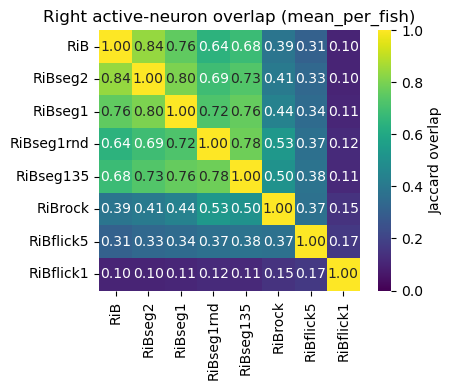

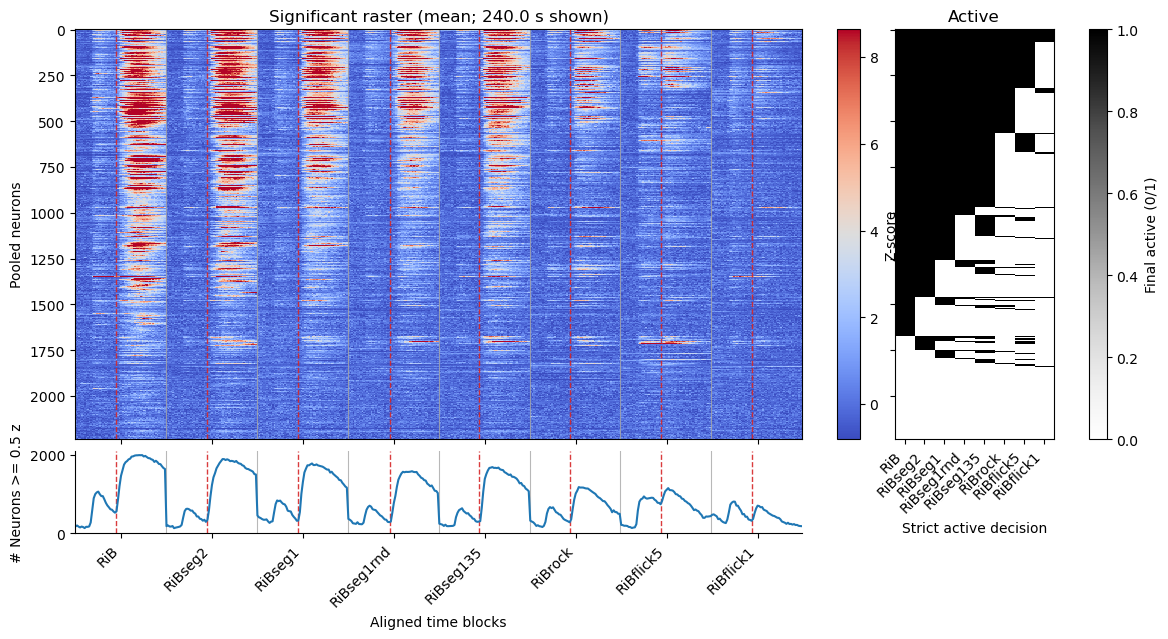

plot_mode: z_score
sort_mode: decision_then_mean
trace_matrix: (2236, 480)
decision_matrix: (2236, 8)


In [7]:
# Cell 07 - Optional: active-neuron overlap and diagnostic
if outputs["overlap_diagnostic"]:
    overlap_left = rsf.resolve_stimulus_set(stimulus_sets["overlap_left"], reference_fish)
    overlap_right = rsf.resolve_stimulus_set(stimulus_sets["overlap_right"], reference_fish)
    side_stimulus_ids = {"left": overlap_left["stimulus_ids"], "right": overlap_right["stimulus_ids"]}
    side_stimulus_labels = {"left": overlap_left["stimulus_labels"], "right": overlap_right["stimulus_labels"]}
    overlap_config = settings["overlap_diagnostic"]
    overlap_data = rsf.build_overlap_diagnostic_data(
        all_fish_data=all_fish_data,
        active_matrices=active_matrices,
        fish_ids=fish_ids,
        side_stimulus_ids=side_stimulus_ids,
        side_stimulus_labels=side_stimulus_labels,
        response_row_metadata=response_row_metadata,
        keep_mask=plot_neuron_keep_mask,
        side_to_plot=overlap_config["side"],
        aggregation=overlap_config["aggregation"],
        plot_mode=overlap_config["plot"],
        combine_mode=overlap_config["combine_mode"],
        sort_mode=overlap_config["sort_mode"],
        metric_table=neuron_summary_table,
    )

    display(overlap_data["overlap_results"]["pooled"]["left"])
    display(overlap_data["overlap_results"]["pooled"]["right"])

    fig, ax = plt.subplots(figsize=overlap_config["heatmap_figsize"])
    sns.heatmap(
        overlap_data["matrix_to_plot"],
        vmin=0,
        vmax=1,
        square=True,
        annot=overlap_config["heatmap_annot"],
        fmt=".2f",
        cmap=overlap_config["heatmap_cmap"],
        cbar_kws={"label": "Jaccard overlap"},
        ax=ax,
    )
    ax.set_title(f"{overlap_config['side'].capitalize()} active-neuron overlap ({overlap_config['aggregation']})")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    diagnostic = overlap_data["active_trace_diagnostic"]
    if diagnostic["trace_matrix"].shape[0] == 0:
        print("No neurons passed the current filters; diagnostic plot was not drawn.")
    else:
        fig, axes, diagnostic_neuron_order = plott.plot_active_trace_decision_diagnostic(
            diagnostic,
            fps_2p=timing["fps_2p"],
            stimuli_durations=stimuli_durations,
            t_pre_s=timing["t_pre_s"],
            sort_mode=None,
            neuron_order=overlap_data["diagnostic_neuron_order"],
            trace_cmap="Greys" if overlap_config["plot"] == "significant_raster" else "coolwarm",
            show_active_count_trace=overlap_config["show_active_count"],
            active_count_threshold=overlap_config["active_count_threshold"],
            active_count_ylabel=(
                "# Active neurons"
                if overlap_config["plot"] == "significant_raster"
                else f"# Neurons >= {overlap_config['active_count_threshold']} z"
            ),
            figsize=(12, 7),
        )
        if overlap_config["plot"] == "z_score":
            trace_im = axes[0].images[0]
            finite_trace = diagnostic["trace_matrix"][np.isfinite(diagnostic["trace_matrix"])]
            if finite_trace.size:
                trace_im.set_clim(np.nanpercentile(finite_trace, 2), np.nanpercentile(finite_trace, 98))
            trace_colorbar_axis = fig.axes[2] if overlap_config["show_active_count"] else fig.axes[1]
            trace_colorbar_axis.set_ylabel("Z-score")
        plt.show()

    print("plot_mode:", overlap_config["plot"])
    print("sort_mode:", overlap_config["sort_mode"])
    print("trace_matrix:", diagnostic["trace_matrix"].shape)
    print("decision_matrix:", diagnostic["decision_matrix"].shape)


In [8]:
# Cell 08 - Optional: save this run as a report
# Save the notebook first if you want the PDF/HTML export to include the latest outputs.
notebook_path = repo_root / "scripts" / "calcium_analysis" / "several_fish_reusable_analysis.ipynb"

report_tables = {
    "shape_summary": shape_summary,
    "plot_filter_table": plot_filter_table,
    "neuron_summary_table": neuron_summary_table,
    "neuron_summary_all_stimuli_table": neuron_summary_all_stimuli_table,
}
if "response_window_validation" in globals() and response_window_validation is not None:
    report_tables["response_window_validation"] = response_window_validation
if "segment_similarity_df" in globals() and segment_similarity_df is not None:
    report_tables["segment_similarity_df"] = segment_similarity_df

report_result = rsf.save_analysis_report_run(
    settings=settings,
    report_settings=REPORT_SETTINGS,
    analysis_path=analysis_path,
    tables=report_tables,
    notebook_path=notebook_path,
    extra_metadata={
        "main_plot_stimuli": plot_stimulus_labels,
        "response_stimuli": response_stimulus_labels,
        "plot_neurons_kept": int(plot_neuron_keep_mask.sum()),
        "plot_neurons_total": int(plot_neuron_keep_mask.size),
    },
)
report_result


Report saving is off. Set REPORT_SETTINGS['save_report'] = True to save this run.
